### 📘 Theory & Key Functions
**Theoretical Recall:** Maximum Likelihood Estimation (MLE) fits a statistical model to data by finding the parameters that maximize the likelihood of the observations. For a Multivariate Gaussian, this simply means computing the empirical mean $\mu$ and covariance matrix $\Sigma$. We compute the *log*-likelihood (the sum of log-probabilities) to prevent numerical underflow when multiplying many small probability values.

**Key Functions (from `logpdf_GAU_ND.py`):**
- `logpdf_GAU_ND(x, mu, C)`: Computes the log-density of a Multivariate Gaussian distribution using the log-determinant and the Mahalanobis distance.
- `loglikelihood(X, mu, C)`: Sums the individual log-densities over an entire dataset to evaluate the overall goodness of fit.

See the implementations in [logpdf_GAU_ND.py](../scripts/logpdf_GAU_ND.py).

In [6]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from scripts.utils import *
from scripts.logpdf_GAU_ND import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
D,L,labels=init_dataset()
D,L,labels

(array([[ 1.85284048, -0.21530775,  0.04653456, ..., -0.06393955,
          1.06665359, -0.47186462],
        [-0.16436898,  1.63665974, -1.16487257, ..., -0.92205024,
          3.27717415, -0.37118987],
        [ 1.09839078, -0.61831145,  0.04392191, ...,  1.65445602,
         -0.53087884, -1.04041218],
        [-0.93073689,  0.99002204, -0.41369086, ..., -1.527528  ,
          1.42338924, -0.253746  ],
        [-1.0193342 ,  0.38670252, -1.08847926, ...,  1.87609599,
         -1.11381038, -0.02120134],
        [ 1.16696309,  1.15926273, -1.37988988, ...,  0.75929015,
         -0.15047129, -1.4376229 ]], shape=(6, 6000)),
 array([1., 0., 1., ..., 1., 0., 0.], shape=(6000,)),
 {1: 'True', 0: 'False'})

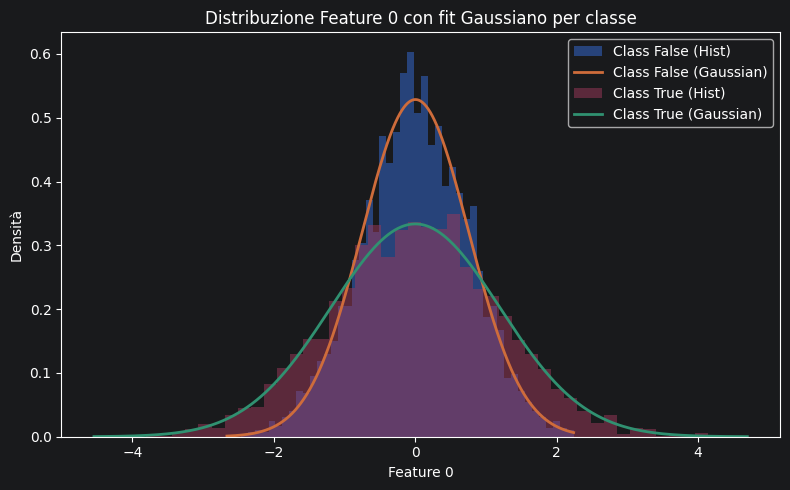

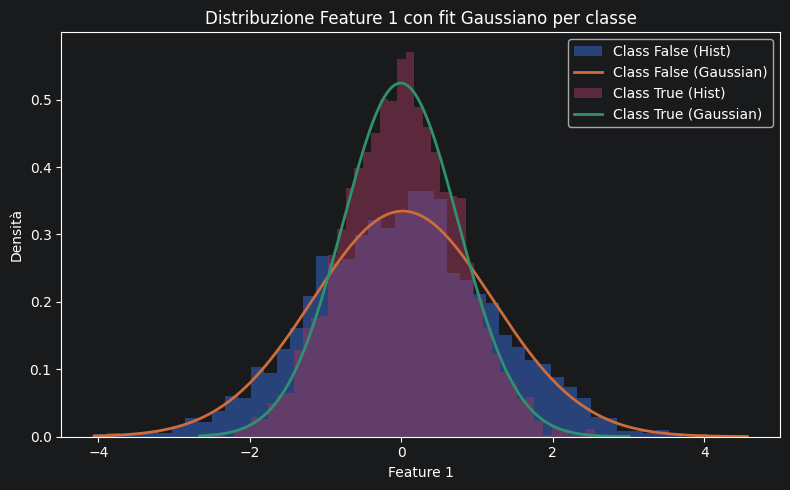

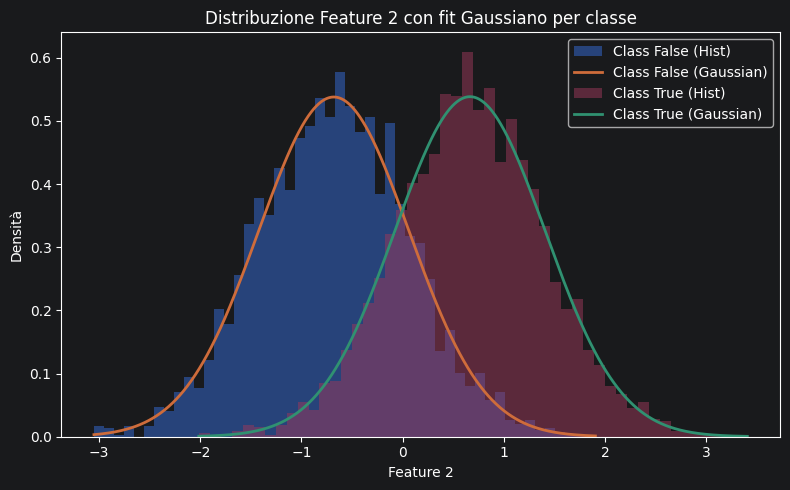

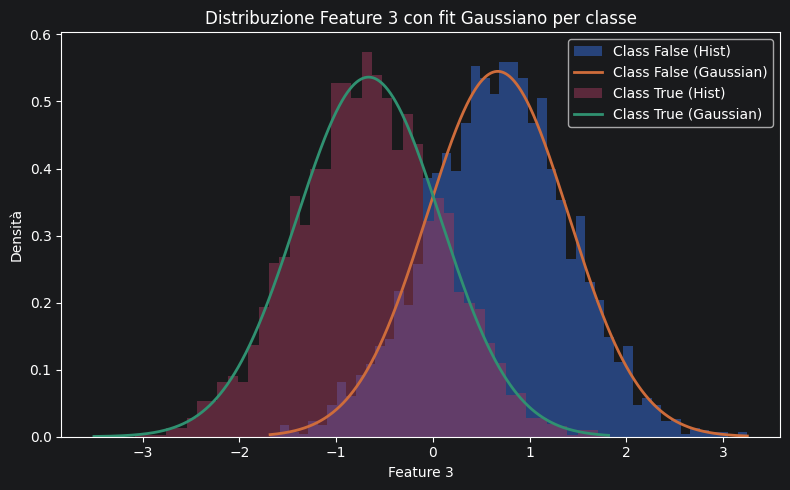

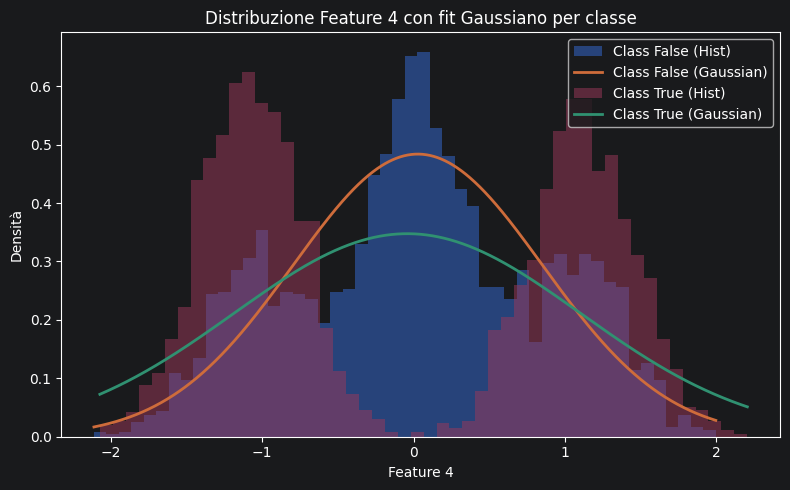

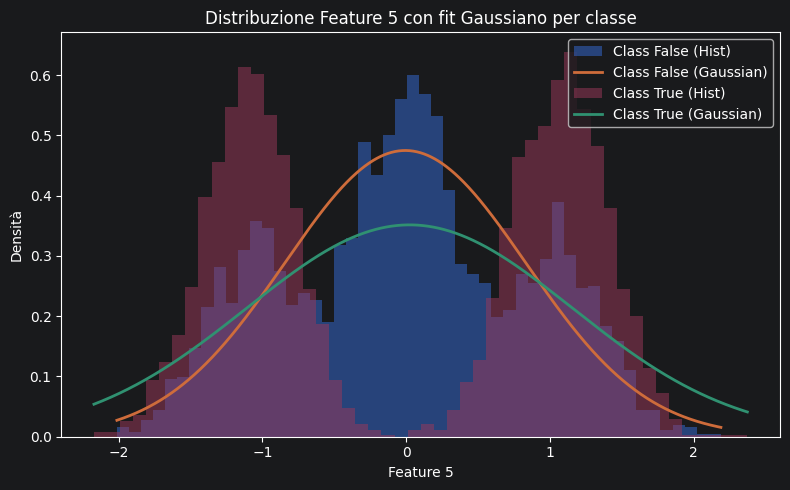

In [8]:
n_features = D.shape[0]
for i in range(n_features):
    plt.figure(figsize=(8, 5))

    for cnt in range(2):
        mask = L == cnt
        D0 = vRow(D[i, mask])
        mu = getMu(D0)
        C = getC(D0)

        plt.hist(D0.ravel(), bins=50, density=True, alpha=0.5, label=f'Class {labels[cnt]} (Hist)')
        XPlot = np.linspace(D0.min(), D0.max(), 1000)
        pdf_values = np.exp(logpdf_GAU_ND(vRow(XPlot), mu, C))
        plt.plot(XPlot.ravel(), pdf_values.ravel(), linewidth=2, label=f'Class {labels[cnt]} (Gaussian)')

    plt.title(f'Distribuzione Feature {i} con fit Gaussiano per classe')
    plt.xlabel(f'Feature {i}')
    plt.ylabel('Densità')
    plt.legend()
    plt.tight_layout()
    plt.show()